## Sagnac Frequency - Backscatter Correction - Compare Setups

Explore the longterm behaviour of the RV sagnac beat

## Imports

In [1]:
import os
import gc
import matplotlib.pyplot as plt
import numpy as np

from datetime import datetime, date
from pandas import DataFrame, read_pickle, date_range, concat, read_csv
from obspy import UTCDateTime, read, Trace, Stream, read_inventory
from scipy.signal import hilbert
from scipy.ndimage import gaussian_filter1d


import sys
sys.path.append("../")

from functions.get_fft import __get_fft
from functions.multitaper_psd import __multitaper_psd
from functions.welch_psd import __welch_psd
from functions.rotate_romy_ZUV_ZNE import __rotate_romy_ZUV_ZNE
from functions.reduce import __reduce
from functions.load_backscatter_data import __load_backscatter_data
from functions.backscatter_correction import __backscatter_correction

from functions.read_sds import __read_sds

In [2]:
if os.uname().nodename == 'lighthouse':
    root_path = '/home/andbro/'
    data_path = '/home/andbro/kilauea-data/'
    archive_path = '/home/andbro/freenas/'
    bay_path = '/home/andbro/ontap-ffb-bay200/'
    lamont_path = '/home/andbro/lamont/'
elif os.uname().nodename == 'kilauea':
    root_path = '/home/brotzer/'
    data_path = '/import/kilauea-data/'
    archive_path = '/import/freenas-ffb-01-data/'
    bay_path = '/import/ontap-ffb-bay200/'
    lamont_path = '/lamont/'
elif os.uname().nodename in ['lin-ffb-01', 'ambrym', 'hochfelln']:
    root_path = '/home/brotzer/'
    data_path = '/import/kilauea-data/'
    archive_path = '/import/freenas-ffb-01-data/'
    bay_path = '/import/ontap-ffb-bay200/'
    lamont_path = '/lamont/'

## Configurations

In [3]:
config = {}

config['ring'] = "Z"

# config['delta'] = 120

# switch of PDs for monobeams at RZ & new control loop
# config['tbeg'] = UTCDateTime("2024-10-23 15:00")
# config['tend'] = UTCDateTime("2024-10-23 16:00")

config['tbeg'] = UTCDateTime("2023-09-08 22:00")
config['tend'] = UTCDateTime("2023-09-08 23:00")


# path to Sagnac data
config['path_to_data1'] = archive_path+"romy_archive/"
config['path_to_data2'] = data_path+"sagnac_frequency/data/demod/"

# config['path_to_out_data'] = data_path+"sagnac_frequency/data/"

# path to out figures
config['path_to_figs'] = data_path+"sagnac_frequency/figures/"


In [4]:
inv = read_inventory(data_path+"stationxml_ringlaser/"+"station_BW_ROMY.xml")

In [52]:
st1 = __read_sds(config['path_to_data1'], "BW.ROMY.10.BJZ", config['tbeg'], config['tend'])

st1 = st1.remove_sensitivity(inv)

st1 = st1.detrend("demean")

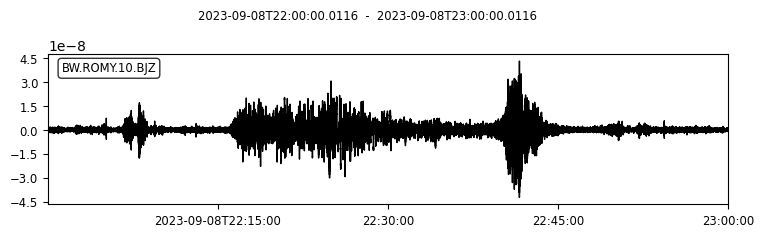

In [53]:
st1.plot();

In [117]:
# reference 20 [ f=10Hz, CA(off), AS(off), ]
# st2 = __read_sds(config['path_to_data2'], "BW.ROMY.20.BJZ", config['tbeg'], config['tend'])

# reference 21 [ f=10Hz, CA(on), SS(off), ]
# st2 = __read_sds(config['path_to_data2'], "BW.ROMY.21.BJZ", config['tbeg'], config['tend'])

# reference 22 [ f=10Hz, CA(off), SS(on), ]
# st2 = __read_sds(config['path_to_data2'], "BW.ROMY.22.BJZ", config['tbeg'], config['tend'])

# reference 23 [ f=10Hz, CA(on), SS(on), ]
st2 = __read_sds(config['path_to_data2'], "BW.ROMY.23.BJZ", config['tbeg'], config['tend'])


In [118]:
# scaling correction
for tr in st2:
    tr.data *= 0.75

In [119]:
%matplotlib inline

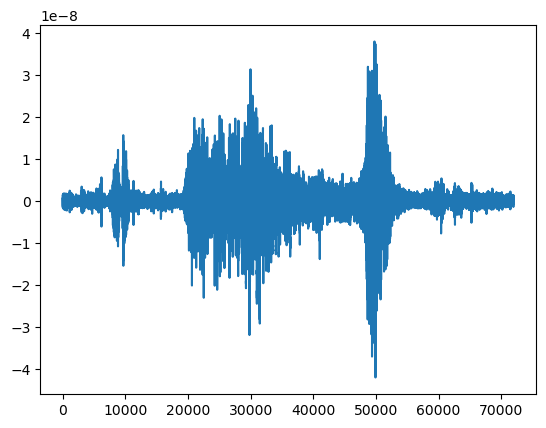

In [120]:
plt.figure()
plt.plot(st2[0].data)

In [121]:
f1, s1, p1 = __get_fft(st1[0].data, st1[0].stats.delta, window="hann")
f2, s2, p2 = __get_fft(st2[0].data, st2[0].stats.delta, window="hann")

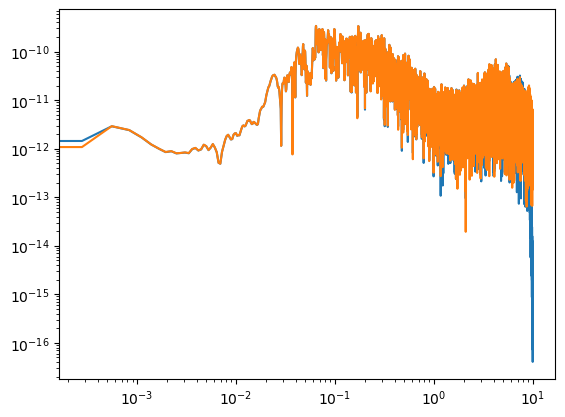

In [122]:
plt.figure()
plt.loglog(f1, s1)
plt.loglog(f2, s2)

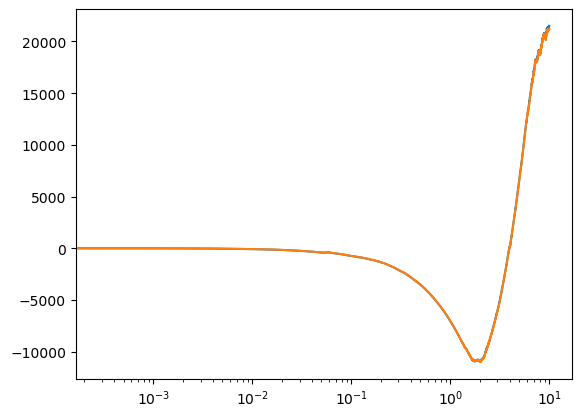

In [124]:
plt.figure()
plt.plot(f1, np.unwrap(p1 + np.pi))
plt.plot(f2, np.unwrap(p2 + np.pi))

plt.xscale("log")
# plt.yscale("log")

In [125]:
st10 = st1.copy()
st20 = st2.copy()
st10.detrend("demean")
st10.filter("bandpass", freqmin=0.01, freqmax=0.1, corners=4, zerophase=True)
st20.detrend("demean")
st20.filter("bandpass", freqmin=0.01, freqmax=0.1, corners=4, zerophase=True)

1 Trace(s) in Stream:
BW.ROMY.23.BJZ | 2023-09-08T22:00:00.000000Z - 2023-09-08T22:59:59.950000Z | 20.0 Hz, 72000 samples

In [126]:
%matplotlib tk

plt.figure()
plt.plot(st10[0].times(reftime=config['tbeg']), st10[0].data)
plt.plot(st20[0].times(reftime=config['tbeg']), st20[0].data)


In [61]:
st1, st2

(1 Trace(s) in Stream:
BW.ROMY.10.BJZ | 2023-09-08T22:00:00.011600Z - 2023-09-08T23:00:00.011600Z | 20.0 Hz, 72001 samples,
 1 Trace(s) in Stream:
BW.ROMY.45.BJZ | 2023-09-08T22:00:00.000000Z - 2023-09-08T22:59:59.950000Z | 20.0 Hz, 72000 samples)

In [16]:
from functions.sagnac_to_tilt import __sagnac_to_tilt

In [17]:
def __get_scalefactor(ring="Z"):

    from numpy import pi, sqrt, arccos, deg2rad, arcsin, cos, sin, array, zeros

    # angle in horizontal plane
    h_rot = {"Z":0, "U":0, "V":60, "W":60}

    # angle from vertical
    v_rot = {"Z":0, "U":109.5, "V":70.5, "W":70.5}
    # v_rot = {"Z":-90, "U":19.5, "V":-19.5, "W":-19.5}

    # side length
    L = {"Z":11.2, "U":12, "V":12, "W":12}

    # wavelength
    lamda = 632.8e-9

    # Scale factor
    S = (sqrt(3)*L[ring])/(3*lamda)

    # ROMY latitude
    lat = deg2rad(48.162941)
    lon = deg2rad(11.275501)

    # nominal Earth rotation
    omegaE = 2*pi/86400 * array([0, 0, 1])

    # matrix 1
    D = array([[-sin(lat)*cos(lon), -sin(lon), cos(lat)*cos(lon)],
               [sin(lat)*sin(lon), cos(lon), cos(lat)*sin(lon)],
               [cos(lat), 0, sin(lat)]
              ])

    # tilt
    da = deg2rad(0)
    dz = deg2rad(0)

    # tilt matrix
    R = array([[1, -da, -dz], [da,  1, 0], [dz, 0, 1]])

    pv = deg2rad(v_rot[ring])
    ph = deg2rad(h_rot[ring])

    # normal vector of ring
    nx = array([[sin(pv)*cos(ph)], [sin(pv)*sin(ph)], [cos(pv)]])

    one = array([0, 0, 1])

    out = S * ( one @ ( D @ (R @ nx) ) )[0]

    return out

In [18]:
__get_scalefactor(ring="Z")

7613305.75491683